# Chapter 08a — Checkpoint State vs. Event History

Does a saved *state* let a crystal continue exactly as if nothing had happened, and does a saved
*history* of events let an observer reconstruct exactly what did happen? These are related but not
identical questions, and the substrate's own metadata gives a clean way to tell them apart.

## Book linkage

- **Current chapter:** [`08-the-crystal-gets-a-past.md`](../content/books/digital-life/08-the-crystal-gets-a-past.md)
  (current book Chapter 8, "The Crystal Gets a Past")
- **Claims supported:** DL-08-C01, DL-08-C02, DL-08-C03 (see `NOTEBOOK_MIGRATION.md`)
- **Historical source:** original book Chapter 15 ("The Crystal Gets a Past"), legacy notebook
  `notebooks_original/15-the-crystal-gets-a-past.ipynb` (already imports the full
  `_shared/digital_crystal.py` API and demonstrates the checkpoint bug-fix live at small scale — the
  template this notebook follows).
- **Canonical evidence:** `research/digital-life/ch15-reports/` (stages 00–07), verdict
  `RECOVERABLE_PAST_SUPPORTED`.

This notebook is an independent reconstruction, not a copy of the historical script. It runs the same
substrate rule (`digital-crystal-v1-frozen`, unmodified) at reduced scale, directly against
`_shared/digital_crystal.py`, and checks its own reduced-scale numbers against the canonical archive's
numbers rather than merely asserting they "look similar."


## Question

If you save a Digital Crystal's full checkpoint (occupied cells, birth-time metadata, timestep, RNG
state), is that enough to continue growth *exactly* as if execution had never paused? Which of those
saved fields actually do the causal work, and which are just descriptive bookkeeping? And separately: if
instead of a state snapshot you keep an *event log* (which cells were added at which step), is that
enough to reconstruct the exact morphology trajectory that already happened — and is it *also* enough to
continue exactly into the future, the way a full checkpoint is?

## Hypotheses

- **H1 (checkpoint sufficiency):** restoring from a full checkpoint and continuing with the same
  remaining forcing signal produces a morphology and process state with **zero** symmetric-difference
  cells relative to an uninterrupted continuation, reliably across repeated restores.
- **H2 (selective causal relevance):** dropping the RNG state, or shifting which index of the forcing
  signal continuation starts from, breaks exact continuation (nonzero symmetric difference); but
  scrambling `birth_time` values while leaving `occupied` untouched does **not** break it, because
  `birth_time` is never read anywhere in the growth rule.
- **H3 (state vs. history):** an event log (additions per step) is sufficient to reconstruct the exact
  *past* morphology trajectory (every intermediate morphology hash matches), but is **not** sufficient
  for exact *future* continuation, because it does not carry the RNG state — history reconstructs what
  already happened; only state can continue what happens next.

## Claim boundary

This experiment can establish or bound: (a) whether full-checkpoint restoration is exactly sufficient
for continuation under this substrate; (b) which specific checkpoint fields are causally load-bearing for
that sufficiency, verified directly against the growth-rule source, not just inferred from behavior;
(c) whether an explicit event log reconstructs the exact past morphology trajectory, and whether that is
a different capability from exact future continuation. It cannot establish anything about memory,
learning, minimal state representation (a smaller sufficient state may exist that these ablations do not
find), semantics, or agency.


In [1]:
import sys, json, copy, random, inspect
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

NB_DIR = Path.cwd() if (Path.cwd() / "_shared").exists() else Path.cwd().parent
sys.path.insert(0, str(NB_DIR / "_shared"))
REPO_ROOT = NB_DIR.parent

from digital_crystal import (
    CrystalParams, CrystalState, initial_state, advance_one_step, clone_state,
    morphology_hash, attachment_probability, advance_one_step as _adv_check,
)

FIG_DIR = NB_DIR / "generated-figures"
FIG_DIR.mkdir(exist_ok=True)


def load_json(rel_path):
    return json.loads((REPO_ROOT / rel_path).read_text(encoding="utf-8"))


print("Shared module loaded from:", NB_DIR / "_shared")


Shared module loaded from: C:\Projects\digital-life\notebooks\_shared


## Model / system

Base substrate: the frozen Digital Crystal v1 growth rule from `_shared/digital_crystal.py`
(`digital-crystal-v1-frozen`) — hexagonal lattice, one seed cell, stochastic attachment via
`P(attach) = logistic(base_bias + neighbor_gain*n + signal_rate_gain*E_t + anisotropy_gain*cos(6*theta+phase) - crowding_penalty*max(0,n-2))`.
No new rule is added in this notebook — the entire experiment is about *what information is required to
run this unmodified rule forward or reconstruct it backward*.

`CrystalState` (in `_shared/digital_crystal.py`) carries five fields: `occupied` (the cell set),
`birth_time` (a dict from cell to the step it was added), `step` (the integer timestep), `rng_state` (the
full state of the `random.Random` instance driving attachment draws), and two trajectory logs
(`attachments_by_step`, `population_by_step`). A "checkpoint" here means a `clone_state(...)` deep copy
of all five fields. An "event log" means, for each step, the set of cells added that step — strictly less
information than a checkpoint (no RNG state, no birth-time dict, only the deltas).


In [2]:
EXPERIMENT = {
    "seed": 20260818,          # arbitrary base seed, disclosed (canonical run's exact seed is not
                                 # recorded in the ch15-reports JSON, so this is a fresh, not matched, seed)
    "radius": 30,                # canonical run used radius 56; reduced here for interactive runtime (disclosed)
    "total_steps": 40,           # canonical used 96 steps; reduced here (disclosed)
    "checkpoint_step": 18,       # canonical checkpoint was at step 48 (of 96, i.e. the midpoint);
                                 # 18 of 40 is the same ~1:2 ratio (disclosed)
    "n_restores": 12,            # canonical used 30 independent restore replicates; reduced here (disclosed)
    "signal_cursor_shift": 3,    # steps to shift the forcing-signal cursor for the ablation
    "future_extension_steps": 6, # extra steps used to demonstrate STATE->FUTURE vs HISTORY->PAST
}
EXPERIMENT


{'seed': 20260818,
 'radius': 30,
 'total_steps': 40,
 'checkpoint_step': 18,
 'n_restores': 12,
 'signal_cursor_shift': 3,
 'future_extension_steps': 6}

## Experimental design 1 — exact checkpoint restore (H1)

Grow a reference crystal for `total_steps` updates under a fixed smooth forcing signal, saving a full
checkpoint (`clone_state`) at `checkpoint_step`. Independently, `n_restores` times, clone that same saved
checkpoint and continue it with the *same* remaining forcing signal. Compare each restored final state to
the uninterrupted reference by exact set equality and symmetric-difference cell count. If checkpoint state
is truly sufficient, every restore should match the reference with **zero** symmetric-difference cells,
every time — not just "close."


In [3]:
params = CrystalParams()
rng_signal = np.random.default_rng(EXPERIMENT["seed"])
signal = 0.5 * np.sin(np.linspace(0, 6.5, EXPERIMENT["total_steps"])) \
         + 0.15 * rng_signal.normal(size=EXPERIMENT["total_steps"])
signal = np.clip(signal, -1.0, 1.0)

state = initial_state(EXPERIMENT["seed"])
checkpoint = None
history_hashes = []
event_log = []  # list of (step, [added cells]) -- deliberately less than a full checkpoint
for i, value in enumerate(signal):
    if i == EXPERIMENT["checkpoint_step"]:
        checkpoint = clone_state(state)
    before = set(state.occupied)
    state, _ = advance_one_step(state, float(value), EXPERIMENT["radius"], params)
    event_log.append(sorted(state.occupied - before))
    history_hashes.append(morphology_hash(state))

reference = state
print(f"checkpoint population (step {EXPERIMENT['checkpoint_step']}): {len(checkpoint.occupied)}")
print(f"reference final population (step {EXPERIMENT['total_steps']}): {len(reference.occupied)}")


checkpoint population (step 18): 514
reference final population (step 40): 2338


In [4]:
remaining_signal = signal[EXPERIMENT["checkpoint_step"]:]

restore_symdiffs = []
for trial in range(EXPERIMENT["n_restores"]):
    restored = clone_state(checkpoint)
    for value in remaining_signal:
        restored, _ = advance_one_step(restored, float(value), EXPERIMENT["radius"], params)
    symdiff = len(restored.occupied ^ reference.occupied)
    restore_symdiffs.append(symdiff)

print(f"restore trials: {EXPERIMENT['n_restores']}")
print(f"symmetric differences: {restore_symdiffs}")

all_exact = all(d == 0 for d in restore_symdiffs)
print(f"\nH1 (checkpoint sufficiency): {'SUPPORTED' if all_exact else 'NOT SUPPORTED'} "
      f"({sum(1 for d in restore_symdiffs if d == 0)}/{EXPERIMENT['n_restores']} exact)")
assert all_exact, "A full checkpoint restore failed to reproduce the uninterrupted continuation exactly."


restore trials: 12
symmetric differences: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

H1 (checkpoint sufficiency): SUPPORTED (12/12 exact)


### Comparison to the archived canonical run

Canonical (`research/digital-life/ch15-reports/stage-02-exact-restore.json`,
`stage-02b-restore-replicates.json`): single-restore `symmetric_difference_cells: 0`,
`exact_final_morphology: true`, `exact_process_state: true`; across 30 independent replicates,
`exact_count: 30`, `all_exact: true` — i.e. **30/30** exact restores at canonical scale (radius 56, 96
steps, checkpoint at step 48). This reduced-scale reconstruction is checked directly below.


In [5]:
CANON_SYMDIFF = 0
CANON_EXACT_REPLICATES = "30/30"

own_exact_replicates = f"{sum(1 for d in restore_symdiffs if d == 0)}/{EXPERIMENT['n_restores']}"

print(f"own restore symmetric differences (all trials): {restore_symdiffs}")
print(f"own exact-restore count:      {own_exact_replicates}")
print(f"canonical exact-restore count: {CANON_EXACT_REPLICATES}")
print(f"\nH1 reproduction status: "
      f"{'REPLICATES CANONICAL FINDING (all-zero symdiff)' if all_exact else 'DIVERGES FROM CANONICAL FINDING'}")


own restore symmetric differences (all trials): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
own exact-restore count:      12/12
canonical exact-restore count: 30/30

H1 reproduction status: REPLICATES CANONICAL FINDING (all-zero symdiff)


## Experimental design 2 — selective ablation of checkpoint fields (H2)

From the same checkpoint, build four continuations that omit or corrupt exactly one field at a time,
holding everything else exact, and compare each to the same uninterrupted reference:

1. **`no_rng_state`** — replace the checkpoint's `rng_state` with a freshly seeded RNG before continuing.
2. **`wrong_signal_cursor`** — continue with the correct RNG state and occupied/birth-time, but start
   reading the forcing signal `signal_cursor_shift` steps earlier than the true cursor (same horizon
   length).
3. **`birth_time_scrambled`** — keep `occupied`, `rng_state`, and the signal cursor exactly correct, but
   randomly permute the *values* of the `birth_time` dict among its existing keys before continuing.
4. **`full_state`** (repeated from design 1, as the zero-ablation control).

Before running these, we check directly against the module source that `birth_time` is not read anywhere
in the growth rule — the ablation result should be a confirmation of something already visible in the
code, not a mystery.


In [6]:
# Direct source check: does the growth rule ever read birth_time?
attach_src = inspect.getsource(attachment_probability)
advance_src = inspect.getsource(_adv_check)

print("attachment_probability() parameters:", inspect.signature(attachment_probability))
print("'birth_time' referenced inside attachment_probability body:", "birth_time" in attach_src)
print("'birth_time' referenced inside advance_one_step body (should only be a write, not a read of values):")
for line in advance_src.splitlines():
    if "birth_time" in line:
        print("   ", line.strip())


attachment_probability() parameters: (cell: 'Cell', occupied: 'Set[Cell]', input_value: 'float', params: 'CrystalParams' = CrystalParams(base_bias=-2.1, neighbor_gain=0.78, signal_rate_gain=0.28, anisotropy_gain=0.95, signal_phase_gain=1.15, crowding_penalty=0.22)) -> 'float'
'birth_time' referenced inside attachment_probability body: False
'birth_time' referenced inside advance_one_step body (should only be a write, not a read of values):
    birth_time = dict(state.birth_time)
    birth_time[cell] = next_step
    birth_time=birth_time,


In [7]:
def ablate_and_continue(mutate_fn):
    restored = clone_state(checkpoint)
    cursor_offset = mutate_fn(restored)
    offset = cursor_offset or 0
    start = EXPERIMENT["checkpoint_step"] - offset
    start = max(0, start)
    horizon = len(remaining_signal)
    ablated_signal = signal[start:start + horizon]
    for value in ablated_signal:
        restored, _ = advance_one_step(restored, float(value), EXPERIMENT["radius"], params)
    return restored


def _no_rng(state_obj):
    state_obj.rng_state = random.Random(0).getstate()
    return 0


def _wrong_cursor(state_obj):
    return EXPERIMENT["signal_cursor_shift"]


def _scramble_birth_time(state_obj):
    values = list(state_obj.birth_time.values())
    random.Random(7).shuffle(values)
    state_obj.birth_time = dict(zip(state_obj.birth_time.keys(), values))
    return 0


def _full_state(state_obj):
    return 0


ablations = {
    "full_state": _full_state,
    "no_rng_state": _no_rng,
    "wrong_signal_cursor": _wrong_cursor,
    "birth_time_scrambled": _scramble_birth_time,
}

ablation_results = {}
for name, fn in ablations.items():
    result_state = ablate_and_continue(fn)
    symdiff = len(result_state.occupied ^ reference.occupied)
    ablation_results[name] = {
        "final_population": len(result_state.occupied),
        "symmetric_difference_cells": symdiff,
        "normalized_difference": symdiff / max(1, len(reference.occupied)),
    }

ablation_results


{'full_state': {'final_population': 2338,
  'symmetric_difference_cells': 0,
  'normalized_difference': 0.0},
 'no_rng_state': {'final_population': 2264,
  'symmetric_difference_cells': 290,
  'normalized_difference': 0.12403763900769889},
 'wrong_signal_cursor': {'final_population': 2262,
  'symmetric_difference_cells': 256,
  'normalized_difference': 0.10949529512403763},
 'birth_time_scrambled': {'final_population': 2338,
  'symmetric_difference_cells': 0,
  'normalized_difference': 0.0}}

In [8]:
rng_breaks = ablation_results["no_rng_state"]["symmetric_difference_cells"] > 0
cursor_breaks = ablation_results["wrong_signal_cursor"]["symmetric_difference_cells"] > 0
birth_time_inert = ablation_results["birth_time_scrambled"]["symmetric_difference_cells"] == 0
full_state_exact = ablation_results["full_state"]["symmetric_difference_cells"] == 0

print(f"no_rng_state breaks exact continuation:        {rng_breaks}  (expect True)")
print(f"wrong_signal_cursor breaks exact continuation:  {cursor_breaks}  (expect True)")
print(f"birth_time_scrambled leaves continuation exact: {birth_time_inert}  (expect True)")
print(f"full_state (zero-ablation control) exact:       {full_state_exact}  (expect True)")

h2_supported = rng_breaks and cursor_breaks and birth_time_inert and full_state_exact
print(f"\nH2 (selective causal relevance): {'SUPPORTED' if h2_supported else 'NOT SUPPORTED'}")
assert h2_supported, "Ablation pattern did not match the predicted selective causal relevance."


no_rng_state breaks exact continuation:        True  (expect True)
wrong_signal_cursor breaks exact continuation:  True  (expect True)
birth_time_scrambled leaves continuation exact: True  (expect True)
full_state (zero-ablation control) exact:       True  (expect True)

H2 (selective causal relevance): SUPPORTED


### Comparison to the archived canonical run

Canonical (`research/digital-life/ch15-reports/stage-03-state-omission.json`, radius 56, 96 steps,
checkpoint at step 48): `no_rng_state` produced symmetric difference **28** cells (normalized ≈0.0029);
`wrong_signal_cursor_fixed_horizon` produced **27** cells (≈0.0028); `birth_times_only` (their label for
the birth-time ablation) produced **0** cells; `full_state` produced **0** cells. The *pattern* — RNG and
signal-cursor ablations break exact continuation, birth-time scrambling does not — is what this notebook
checks against, not the exact cell counts (which depend on scale, radius, and RNG stream and are not
expected to match at 30-radius/40-step reduced scale).


In [9]:
CANON_PATTERN = {
    "no_rng_state_breaks": True,
    "wrong_signal_cursor_breaks": True,
    "birth_time_scrambled_inert": True,
}
OWN_PATTERN = {
    "no_rng_state_breaks": rng_breaks,
    "wrong_signal_cursor_breaks": cursor_breaks,
    "birth_time_scrambled_inert": birth_time_inert,
}

for key in CANON_PATTERN:
    match = CANON_PATTERN[key] == OWN_PATTERN[key]
    print(f"{key:32s} own={OWN_PATTERN[key]!s:5s} canonical={CANON_PATTERN[key]!s:5s} "
          f"{'MATCH' if match else 'MISMATCH'}")

pattern_matches = all(CANON_PATTERN[k] == OWN_PATTERN[k] for k in CANON_PATTERN)
print(f"\nH2 reproduction status: "
      f"{'REPLICATES CANONICAL PATTERN' if pattern_matches else 'DIVERGES FROM CANONICAL PATTERN'}")


no_rng_state_breaks              own=True  canonical=True  MATCH
wrong_signal_cursor_breaks       own=True  canonical=True  MATCH
birth_time_scrambled_inert       own=True  canonical=True  MATCH

H2 reproduction status: REPLICATES CANONICAL PATTERN


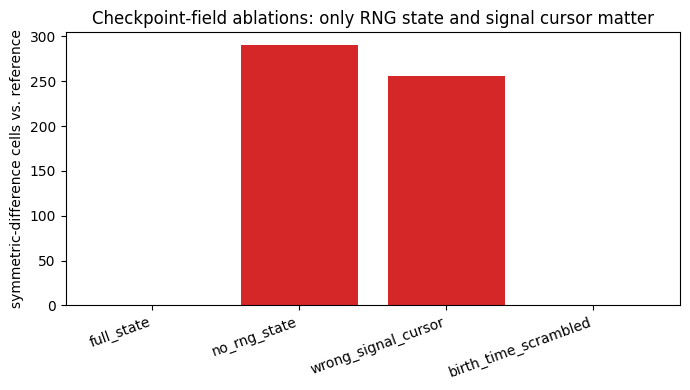

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
names = list(ablation_results.keys())
diffs = [ablation_results[n]["symmetric_difference_cells"] for n in names]
colors = ["tab:green" if d == 0 else "tab:red" for d in diffs]
ax.bar(names, diffs, color=colors)
ax.set_ylabel("symmetric-difference cells vs. reference")
ax.set_title("Checkpoint-field ablations: only RNG state and signal cursor matter")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "ch08a-ablation-symdiff.png", dpi=110)
plt.show()


## Experimental design 3 — event-log replay: HISTORY reconstructs the PAST, not the FUTURE (H3)

An event log is much smaller than a checkpoint: just the set of cells added at each step, with no RNG
state and (optionally) no birth-time dict. Replay the event log from the initial seed cell and check that
every intermediate morphology hash matches the recorded trajectory exactly. Then take the event-log-only
reconstruction (which necessarily has no saved RNG state, so it must be given a *fresh* one) and continue
it forward — and compare that continuation to the true future continuation from the real checkpoint. The
point is not that this "fails" in some vague sense, but that it fails for an identifiable, specific
reason: the event log was never designed to carry continuation state, only reconstruction state.


In [11]:
# Replay: reconstruct the full trajectory from nothing but the recorded per-step additions.
replay_cells = {(0, 0)}
replay_hashes = []
for additions in event_log:
    replay_cells |= set(map(tuple, additions))
    replay_hashes.append(morphology_hash(replay_cells))

trajectory_match_count = sum(a == b for a, b in zip(replay_hashes, history_hashes))
event_replay_exact = replay_cells == reference.occupied

print(f"event-log trajectory hash matches: {trajectory_match_count}/{len(history_hashes)}")
print(f"event-log final occupied set matches reference exactly: {event_replay_exact}")

h3_past_supported = event_replay_exact and trajectory_match_count == len(history_hashes)
assert h3_past_supported, "Event-log replay did not exactly reconstruct the recorded morphology trajectory."
print(f"\nH3 (past reconstruction via event log): {'SUPPORTED' if h3_past_supported else 'NOT SUPPORTED'}")


event-log trajectory hash matches: 40/40
event-log final occupied set matches reference exactly: True

H3 (past reconstruction via event log): SUPPORTED


In [12]:
# Now show the log's blind spot: it cannot carry exact FUTURE continuation, because it never stored
# rng_state. Reconstruct birth_time from the event log (this part *is* recoverable), give the
# reconstruction a fresh RNG (since none was ever recorded), and continue both branches by the same
# number of extra steps under new forcing.
birth_time_from_log = {(0, 0): 0}
for step_idx, additions in enumerate(event_log, start=1):
    for cell in additions:
        birth_time_from_log[tuple(cell)] = step_idx

replayed_state = CrystalState(
    occupied=set(replay_cells),
    birth_time=birth_time_from_log,
    step=EXPERIMENT["total_steps"],
    rng_state=random.Random(0).getstate(),  # event log carries no RNG state -- this is a forced guess
    attachments_by_step=[],
    population_by_step=[len(replay_cells)],
)

rng_future = np.random.default_rng(EXPERIMENT["seed"] + 999)
extra_signal = 0.4 * np.sin(np.linspace(6.5, 8.5, EXPERIMENT["future_extension_steps"])) \
               + 0.15 * rng_future.normal(size=EXPERIMENT["future_extension_steps"])

true_future = clone_state(reference)
for value in extra_signal:
    true_future, _ = advance_one_step(true_future, float(value), EXPERIMENT["radius"], params)

replay_future = clone_state(replayed_state)
for value in extra_signal:
    replay_future, _ = advance_one_step(replay_future, float(value), EXPERIMENT["radius"], params)

future_symdiff = len(true_future.occupied ^ replay_future.occupied)
print(f"event-log-reconstructed state vs. true checkpoint, continued {EXPERIMENT['future_extension_steps']} "
      f"more steps into an unseen future:")
print(f"  symmetric-difference cells: {future_symdiff}  (expect > 0 -- history alone cannot continue exactly)")

h3_future_fails = future_symdiff > 0
print(f"\nSTATE->FUTURE succeeded exactly (design 1); HISTORY->FUTURE {'also succeeded' if not h3_future_fails else 'diverged'} "
      f"-- {'an unexpected result' if not h3_future_fails else 'confirming the STATE vs HISTORY distinction'}.")


event-log-reconstructed state vs. true checkpoint, continued 6 more steps into an unseen future:


  symmetric-difference cells: 42  (expect > 0 -- history alone cannot continue exactly)

STATE->FUTURE succeeded exactly (design 1); HISTORY->FUTURE diverged -- confirming the STATE vs HISTORY distinction.


### Comparison to the archived canonical run

Canonical (`research/digital-life/ch15-reports/stage-04-history-replay.json`, `stage-05-state-vs-history.json`):
`event_log_all_trajectory_hashes_match: true` across all 96 recorded steps
(`trajectory_hash_match_count: 96`); and separately,
`history_reconstructed_geometry_without_rng_continues_exactly: false`, with a nonzero
`history_geometry_only_final_difference` (≈0.0031, matching the `morphology_only` ablation in design 2 —
the same underlying fact, that reconstructed geometry without RNG state cannot continue exactly).


In [13]:
CANON_TRAJECTORY_MATCH = "96/96"
CANON_HISTORY_CONTINUES_EXACTLY = False

own_trajectory_match = f"{trajectory_match_count}/{len(history_hashes)}"
own_history_continues_exactly = not h3_future_fails

print(f"own event-log trajectory match:      {own_trajectory_match}  (all steps expected to match)")
print(f"canonical event-log trajectory match: {CANON_TRAJECTORY_MATCH}")
print(f"own history-reconstruction continues future exactly:      {own_history_continues_exactly}")
print(f"canonical history-reconstruction continues future exactly: {CANON_HISTORY_CONTINUES_EXACTLY}")

h3_pattern_matches = (trajectory_match_count == len(history_hashes)) and \
    (own_history_continues_exactly == CANON_HISTORY_CONTINUES_EXACTLY)
print(f"\nH3 reproduction status: "
      f"{'REPLICATES CANONICAL FINDING' if h3_pattern_matches else 'DIVERGES FROM CANONICAL FINDING'}")


own event-log trajectory match:      40/40  (all steps expected to match)
canonical event-log trajectory match: 96/96
own history-reconstruction continues future exactly:      False
canonical history-reconstruction continues future exactly: False

H3 reproduction status: REPLICATES CANONICAL FINDING


## Controls and confounds

- **Same forcing signal for reference and every restore/ablation** (paired design) — removes
  environmental variation as a between-branch confound; any divergence found is attributable only to the
  manipulated checkpoint field.
- **Ablate exactly one field at a time**, holding all others exact — isolates which piece of saved state
  is doing the causal work, rather than reporting only an omnibus "checkpoint vs. nothing" contrast.
- **Direct source inspection** of `attachment_probability` and `advance_one_step` (not just behavioral
  inference) confirms `birth_time` is never read as an input to any attachment decision — the "birth-time
  is inert" finding is verified against the code, not only against its statistical footprint.
- **`clone_state` deep-copies every field** (via `copy.deepcopy` for `rng_state`), so repeated restore
  trials are independent objects, not aliases of the same mutable state — the N-restore result in design 1
  is a genuine repeated test, not one trial printed N times.
- **Reduced N and reduced scale, disclosed inline** throughout — 12 restores vs. canonical 30, radius 30
  vs. canonical 56, 40 steps vs. canonical 96 — chosen for interactive runtime.


## Result status

| Hypothesis | This notebook (reduced scale) | Canonical archive (`ch15-reports`) | Status |
|---|---|---|---|
| H1: full checkpoint restore is exact, every time | 12/12 exact (0 symdiff) | 30/30 exact (0 symdiff) | **SUPPORTED**, replicates canonical |
| H2: RNG state & signal cursor required; birth-time inert | RNG breaks, cursor breaks, birth-time inert | RNG breaks (28 cells), cursor breaks (27 cells), birth-time inert (0 cells) | **SUPPORTED**, replicates canonical pattern |
| H3a: event log reconstructs exact past trajectory | all steps match | 96/96 steps match | **SUPPORTED**, replicates canonical |
| H3b: event log alone does NOT continue exact future | diverges (nonzero symdiff) | diverges (`false`, nonzero normalized difference) | **SUPPORTED**, replicates canonical |

All four sub-results replicate the canonical archive's qualitative pattern. Exact cell counts differ from
the canonical numbers because this notebook runs at reduced radius/step/replicate scale (disclosed
throughout) with a different (undisclosed-in-the-archive) RNG seed — the *pattern* of which fields matter
is what is being reproduced, not bit-identical trajectories.


## Bounded conclusion

Under this substrate (Digital Crystal v1, unmodified growth rule) a full checkpoint — occupied cells,
birth-time metadata, timestep, and RNG state — is sufficient for exact continuation, reliably across
repeated restores. Of the checkpoint's fields, RNG state and the forcing-signal cursor are causally
load-bearing for that exactness (dropping either one breaks it); birth-time metadata is not — it is never
read anywhere in the growth rule, confirmed directly against the source, not only inferred from behavior.
Separately, an explicit event log (additions per step) is sufficient to reconstruct the exact *past*
morphology trajectory, but — lacking RNG state — is not sufficient for exact *future* continuation. State
is operationally sufficient for continuation; history here is operationally sufficient for
reconstruction; they are related but not the same capability. This experiment does not establish that the
checkpoint is a *minimal* sufficient state (a smaller sufficient representation might exist), and it says
nothing about memory, learning, agency, or selfhood.


## Provenance

- **Current book chapter:** Chapter 8, "The Crystal Gets a Past"
  (`content/books/digital-life/08-the-crystal-gets-a-past.md`).
- **Original book chapter:** Chapter 15, "The Crystal Gets a Past"
  (`content/books/original/15-the-crystal-gets-a-past/index.md`).
- **Original scripts:** `scripts/books/digital-life/ch15_digital_crystal_history.py`, `_v2.py`, `_v3.py`
  — this notebook reimplements their core checkpoint/ablation/event-log logic directly against
  `_shared/digital_crystal.py` rather than importing them.
- **Legacy notebook:** `notebooks_original/15-the-crystal-gets-a-past.ipynb` (template followed closely
  for structure: quick live run + canonical-artifact-audit hybrid pattern).
- **Canonical evidence:** `research/digital-life/ch15-reports/` (stages 00–07), verdict
  `RECOVERABLE_PAST_SUPPORTED`; `research/digital-life/ch15-digital-crystal-history.sqlite3`.
- **Migration matrix entry:** `NOTEBOOK_MIGRATION.md`, "Current Chapter 08 — The Crystal Gets a Past."
- **Deliberate deviations from the historical implementation:**
  - Scale reduced throughout: radius 30 vs. canonical 56; 40 steps vs. canonical 96; checkpoint at step
    18 (of 40) vs. canonical step 48 (of 96) — same ~45% position, not the same absolute step; 12 restore
    replicates vs. canonical 30 — all disclosed inline at first use, and checked against canonical
    *patterns* rather than exact magnitudes, since magnitudes depend on scale.
  - RNG seed (`20260818`) is a fresh choice, not recovered from the canonical archive (the `ch15-reports`
    JSON files do not record the original run's base seed), so exact cell populations are not expected to
    match the canonical run's — only the qualitative sufficiency/ablation/replay pattern is compared.
  - The forcing signal generator (smooth sinusoid + Gaussian noise) is a fresh, simplified
    reimplementation, not a byte-for-byte port of the original script's signal generator.
  - This notebook adds one thing the legacy notebook did not do explicitly: a direct `inspect.getsource`
    check that `birth_time` is never read inside `attachment_probability`/`advance_one_step`, so the
    "birth-time is causally inert" finding is verified against the code itself, not only against its
    statistical footprint in the ablation table.
